# Bares, restaurantes e padarias nos dados abertos da Receita

A Abrasel representa o setor de bares, restaurantes e alimentação fora do lar. Para ver como
esse setor está hoje, usei a base pública de CNPJ da Receita Federal: o cadastro de todas as
empresas do país, atualizado todo mês, aberto para qualquer um baixar.

A ideia é pegar os arquivos crus, limpar, deixar de um jeito que dê para analisar, e responder
três perguntas:

1. Quantas empresas do setor estão ativas hoje?
2. Como evoluiu a abertura de empresas do setor nos últimos cinco anos?
3. Qual o porte predominante dessas empresas (MEI, ME, EPP)?

No meio do caminho apareceu um problema que ninguém avisa antes, e que mudou o plano: os
arquivos são divididos em 10 partes que **não** são fatias de tempo nem faixas de CNPJ. Explico
na seção sobre isso, porque foi o que decidiu o resto da análise.

## Resposta curta

| Pergunta | Resposta |
|---|---|
| Quantas empresas do setor estão ativas hoje | **1.511.132** (em 1.543.267 estabelecimentos, 97,6% matriz) |
| Como evoluiu a abertura nos últimos cinco anos | 2021: 356.849 · 2022: 282.586 · 2023: 268.190 · 2024: 284.904 · 2025: 315.376 |
| Qual o porte predominante | **MEI, com 63,1%** das ativas; microempresa 32,2%; EPP 3,9%; demais 0,7% |

O resto do notebook mostra de onde vieram esses números, o que os dados têm de sujo e por que a
base publicada pela Receita não serve como está para responder isso.

## De onde vêm os dados

A Receita publica o cadastro do CNPJ separado por assunto:

| Arquivo | O que tem dentro | Uma linha por |
|---|---|---|
| **Estabelecimentos** | situação cadastral, endereço, datas, CNAE | estabelecimento (matriz ou filial) |
| **Empresas** | razão social, natureza jurídica, capital social, porte | empresa |
| **Simples** | opção pelo Simples Nacional e pelo MEI | empresa |
| Tabelas de domínio | tradutor de código para nome (CNAE, município, motivo, natureza) | código |

Cada um desses arquivos vem quebrado em 10 partes numeradas de 0 a 9, porque o conjunto todo
passa de 80 GB. Os arquivos chegam **sem cabeçalho**, com as colunas numa ordem que só existe na
documentação oficial (salva em `docs/layout_rfb_cnpj.pdf`).

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd()
if not (RAIZ / "dados").exists():          # se o notebook abrir de dentro de notebooks/
    RAIZ = RAIZ.parent

con = duckdb.connect()
con.execute(f"CREATE VIEW base AS SELECT * FROM read_parquet('{RAIZ}/dados/tratados/base_afl.parquet')")
con.execute(f"CREATE VIEW aberturas AS SELECT * FROM "
            f"read_csv('{RAIZ}/dados/tratados/aberturas_por_ano.csv')")

print(con.sql('''
    SELECT count(*) AS estabelecimentos_do_setor,
           count(DISTINCT cnpj_basico) AS empresas_do_setor
    FROM base
''').df().to_string(index=False))

 estabelecimentos_do_setor  empresas_do_setor
                   5224132            5129800


## Como os arquivos são por dentro

Os tropeços que valem registro, porque explicam decisões do resto do notebook:

- o separador é `;` e **todo** campo vem entre aspas duplas;
- o arquivo não tem cabeçalho;
- o texto está em **Latin-1**, não UTF-8;
- alguns campos têm `;` **dentro** das aspas, tipo `"APT 1.404;BLOCO A"`, e outros têm aspas
  escapadas, tipo uma loja chamada "A". Quem separa a linha no `;` na mão erra essas linhas em
  silêncio, que é o pior tipo de erro;
- apareceram bytes de controle (0x8F, 0x81) espalhados em algumas linhas, que nem o Latin-1
  estrito aceita: por isso a conversão para UTF-8 trata byte a byte e conta o que encontrou.

O exemplo abaixo é uma linha real dos dados, para mostrar como um split simples erra.

In [2]:
import csv

exemplo = '"65103497";"0001";"19";"1";"";"02";"20260212";"00";"";"";"20260212";"7319002";"6399200,8599699";"AVENIDA";"HUGO MUSSO";"2380";"APT 1.404;BLOCO A";"ITAPUA";"29101786";"ES";"5703";"27";"92716745";"";"";"";"";"ARRUDA.SB@HOTMAIL.COM";"";""'

print("campos contando no olho, separando por ';':", len(exemplo.split(";")))
print("campos com um parser de CSV de verdade:      ",
      len(next(csv.reader([exemplo], delimiter=";", quotechar='"'))))

campos contando no olho, separando por ';': 31
campos com um parser de CSV de verdade:       30


## A descoberta que mudou o plano: as 10 partes

O teste sugere baixar **uma** parte de Estabelecimentos e a mesma parte de Empresas, contando que
elas se liguem pelo CNPJ básico. Testei, e não funciona como parece:

- **Empresas 4** é uma faixa contígua de CNPJ básico, de 13.846.068 a 18.421.566. Estabelecimentos
  4 é uma fatia espalhada por todo o cadastro, de 00000000 a 98.819.600. Resultado: só **8,9%**
  dos estabelecimentos do setor encontravam a empresa deles.
- Olhando a fundo, as partes de Estabelecimentos têm **exatamente o mesmo número de linhas** entre
  si (4.753.435 cada, nas partes 1 a 9), e a parte 0 tem 30.008.723. Elas não são fatias de tempo:
  1990 aparece nas partes 4 e 5, com 6.215 e 6.217 estabelecimentos cada. E o mesmo
  estabelecimento não se repete entre partes.
- O que muda de uma parte para outra é a **densidade por ano**. A parte 4 tem 23.929 aberturas do
  setor em 2019 e 1 em 2021. A parte 5 faz o contrário: 2.733 em 2019 e 35.577 em 2021.

O gráfico abaixo mostra isso de forma direta: para cada ano, de qual parte veio cada abertura.
Se eu tivesse somado só algumas partes, a curva teria "crescimento" em 2020 que é só efeito de
cobertura, não do mercado.

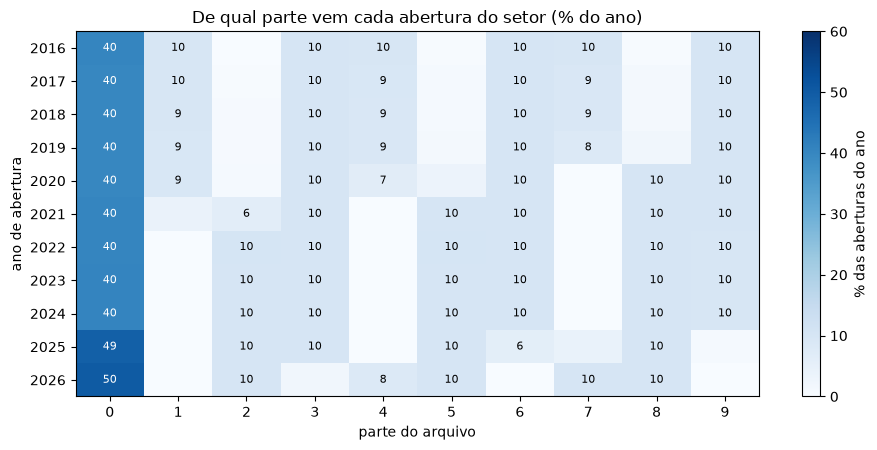

In [3]:
matriz = con.sql('''
    SELECT ano, parte, estabelecimentos
    FROM aberturas
    WHERE ano BETWEEN 2016 AND 2026
''').df()

tabela = matriz.pivot(index="ano", columns="parte", values="estabelecimentos").fillna(0)
proporcao = (tabela.T / tabela.sum(axis=1)).T * 100

fig, ax = plt.subplots(figsize=(9.5, 4.6))
imagem = ax.imshow(proporcao.values, aspect="auto", cmap="Blues", vmin=0, vmax=60)
ax.set_xticks(range(len(proporcao.columns)), proporcao.columns)
ax.set_yticks(range(len(proporcao.index)), proporcao.index)
ax.set_xlabel("parte do arquivo")
ax.set_ylabel("ano de abertura")
ax.set_title("De qual parte vem cada abertura do setor (% do ano)")
for i in range(proporcao.shape[0]):
    for j in range(proporcao.shape[1]):
        valor = proporcao.values[i, j]
        if valor >= 5:
            ax.text(j, i, f"{valor:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if valor > 35 else "black")
plt.colorbar(imagem, label="% das aberturas do ano")
plt.tight_layout()
plt.show()

Por isso baixei **todas as 10 partes** de Estabelecimentos e de Empresas. Com o conjunto completo
são 72.789.638 estabelecimentos lidos, e aí sim as respostas são números do país, não de uma
amostra. De quebra, o casamento entre estabelecimento e empresa ficou em **100%**: nenhuma linha
do setor ficou sem a empresa correspondente, e nenhum estabelecimento apareceu repetido entre
partes.

## Como chegamos na base tratada

O `scripts/02_tratamento.py` faz o trabalho pesado. As decisões que importam:

1. **CNPJ completo.** Estabelecimentos traz o CNPJ partido em três colunas: básico (8 dígitos) +
   ordem (4) + dígito verificador (2). Colei as três, porque o CNPJ básico sozinho não identifica
   o estabelecimento. Conferi os 5.224.132 CNPJs montados com o teste do dígito verificador: todos
   passam.
2. **Datas.** Vêm como texto `YYYYMMDD`. Viram data de verdade, e as inválidas são contadas em vez
   de jogadas fora no silêncio (nesta base, não havia nenhuma).
3. **Filtro do setor.** É do setor quem tem o **CNAE principal** entre os seis códigos de
   alimentação fora do lar. O CNAE secundário ficou guardado na base, mas fora do filtro.
4. **Domínios.** Troquei código por nome em CNAE, município, motivo da situação e natureza
   jurídica. Sem isso a análise vira uma lista de números.
5. **MEI.** Aqui tem uma pegadinha: o campo `porte` da tabela Empresas **não tem** MEI. Só existe
   00 (não informado), 01 (microempresa), 03 (EPP) e 05 (demais). MEI não é porte, é regime
   tributário, e quem sabe disso é a base do Simples. Por isso busquei lá.

In [4]:
resumo = con.sql('''
    SELECT
        count(*)                                     AS estabelecimentos_do_setor,
        count(DISTINCT cnpj_basico)                  AS empresas_do_setor,
        sum(CASE WHEN situacao = 'Ativa' THEN 1 END) AS estabelecimentos_ativos,
        count(DISTINCT CASE WHEN situacao = 'Ativa' THEN cnpj_basico END) AS empresas_ativas,
        count(*) FILTER (WHERE razao_social IS NULL) AS sem_dados_de_empresa
    FROM base
''').df()
resumo

,estabelecimentos_do_setor,empresas_do_setor,estabelecimentos_ativos,empresas_ativas,sem_dados_de_empresa
0,5224132,5129800,1543267.0,1511132,0


## Pergunta 1 — Quantas empresas do setor estão ativas hoje?

"Ativa" é a situação cadastral 02. E tem uma sutileza que muda o número: a tabela é de
**estabelecimentos**, não de empresas. Uma rede com cinco lojas aparece cinco vezes. Então a
conta é de empresas distintas (o CNPJ básico), não de linhas.

In [5]:
ativas = con.sql('''
    SELECT count(*) AS estabelecimentos_ativos,
           count(DISTINCT cnpj_basico) AS empresas_ativas
    FROM base WHERE situacao = 'Ativa'
''').df()
ativas

,estabelecimentos_ativos,empresas_ativas
0,1543267,1511132


Dá **1.511.132 empresas do setor ativas**, espalhadas em 1.543.267 estabelecimentos.

Quase tudo é matriz: só 36.582 estabelecimentos ativos são filial, 2,4% do total. O setor é de
negócio de um endereço só, sem rede.

E para dar escala: dos 5.224.132 estabelecimentos do setor na base, 2.712.323 estão baixados e
947.387 inaptos. Menos de um terço segue ativo. Isso é normal em base de cadastro, que acumula
história.

### Comparando com o número que a Abrasel publica

Vale conferir o resultado contra o que a própria associação divulga. Em notícia de novembro de
2024, a Abrasel falou em "cerca de 1,35 milhão de empresas no setor", sendo 53,31% não-MEI
([abrasel.com.br](https://abrasel.com.br/noticias/noticias/setor-registra-mais-de-148-mil-novas-empresas-em-12-meses/)).

Aqui, com a base de agosto de 2026, são 1.511.132 empresas ativas, com 36,9% não-MEI. Duas
diferenças explicam a distância, e vale dizer que são hipóteses, não certezas:

1. **Data.** São 19 meses de diferença, e foi justamente período de abertura forte de MEI no
   setor, como a série da pergunta 2 mostra. Base mais nova, mais MEI.
2. **Régua de CNAEs.** Aqui entram padaria com revenda (87.081 estabelecimentos ativos) e o
   fornecimento de comida para consumo em casa, que é o delivery (380.242). Se algum desses
   estiver fora do recorte da associação, a composição muda.

Não dá para afirmar qual régua é a certa sem ver a lista de CNAEs usada pelo levantamento deles,
o que a notícia não publica. Fica registrado como checagem, que é o que se pode fazer com dados
públicos.

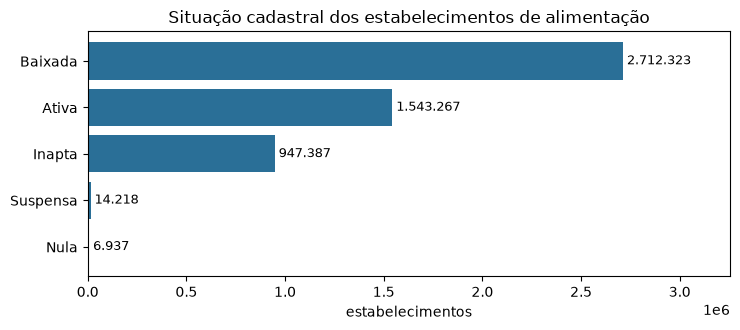

In [6]:
por_situacao = con.sql('''
    SELECT situacao, count(*) AS estabelecimentos
    FROM base GROUP BY 1 ORDER BY 2 DESC
''').df()

fig, ax = plt.subplots(figsize=(7.5, 3.4))
barras = ax.barh(por_situacao["situacao"], por_situacao["estabelecimentos"], color="#2a6f97")
ax.invert_yaxis()
ax.set_xlabel("estabelecimentos")
ax.set_title("Situação cadastral dos estabelecimentos de alimentação")
for barra, valor in zip(barras, por_situacao["estabelecimentos"]):
    ax.text(barra.get_width(), barra.get_y() + barra.get_height() / 2,
            f" {valor:,}".replace(",", "."), va="center", fontsize=9)
ax.margins(x=0.2)
plt.tight_layout()
plt.show()

## Pergunta 2 — Como evoluiu a abertura de empresas do setor

Uso a data de início de atividade de cada estabelecimento para contar quantos começaram em cada
ano. É a melhor informação de abertura que a base tem, mas não é exatamente a data de abertura da
empresa: é o dia em que aquele ponto começou a operar. Uma filial nova de rede velha entra com
data nova; uma empresa que só trocou de atividade mantém a data antiga. Na prática, o gráfico
mede "novos pontos de operação" do setor, que é o que interessa.

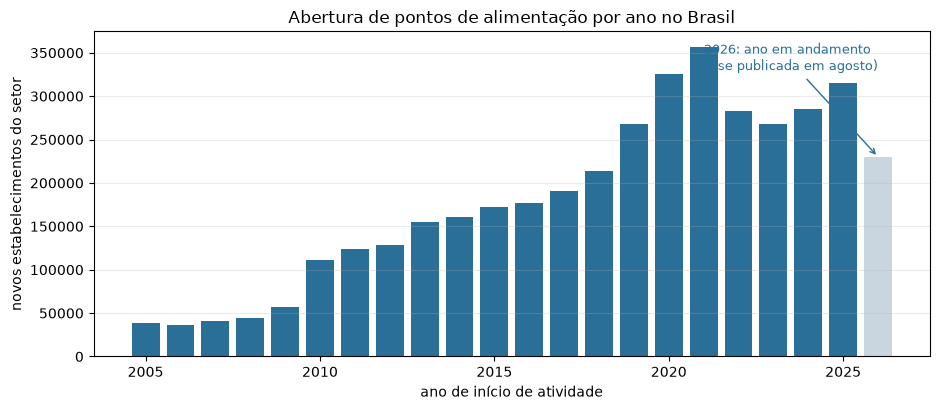

,ano,aberturas,empresas
14,2019,267701,265637
15,2020,325516,324066
16,2021,356849,355195
17,2022,282586,280688
18,2023,268190,266209
19,2024,284904,282682
20,2025,315376,312970
21,2026,230057,228554


In [7]:
por_ano = con.sql('''
    SELECT ano_inicio AS ano,
           count(*)                    AS aberturas,
           count(DISTINCT cnpj_basico) AS empresas
    FROM base
    WHERE ano_inicio BETWEEN 2005 AND 2026
    GROUP BY 1 ORDER BY 1
''').df()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
cores = ["#c9d6df" if ano == 2026 else "#2a6f97" for ano in por_ano["ano"]]
ax.bar(por_ano["ano"], por_ano["aberturas"], color=cores)
ax.set_xlabel("ano de início de atividade")
ax.set_ylabel("novos estabelecimentos do setor")
ax.set_title("Abertura de pontos de alimentação por ano no Brasil")
ax.grid(axis="y", alpha=0.25)
ax.annotate("2026: ano em andamento\n(base publicada em agosto)",
            xy=(2026, por_ano["aberturas"].iloc[-1]), xytext=(2023.4, 330000),
            ha="center", fontsize=9, color="#2a6f97",
            arrowprops=dict(arrowstyle="->", color="#2a6f97", lw=1))
plt.tight_layout()
plt.show()

por_ano.tail(8)

Lendo os cinco anos que a pergunta pede, mais o ano em curso:

| Ano | Aberturas do setor |
|---|---|
| 2021 | 356.849 |
| 2022 | 282.586 |
| 2023 | 268.190 |
| 2024 | 284.904 |
| 2025 | 315.376 |
| 2026 (8 meses) | 230.057 |

A leitura é: 2021 foi o pico, no embalo da formalização em massa de MEI. Depois veio um recuo em
2022 e 2023, e uma retomada a partir de 2024, com 2025 voltando ao patamar de 2021. Em 2026, com
oito meses de base, já são 230 mil aberturas, um ritmo de 345 mil por ano se mantiver.

Vale comparar com o país inteiro, porque o setor não anda sozinho: em 2024 o Brasil abriu
4.844.030 CNPJs, o maior número da série, e o setor representou 5,9% disso. Em 2021, ano de pico
do setor, a fatia era 8,6%. Ou seja: o setor cresceu em número absoluto, mas cresceu menos que o
resto do país.

In [8]:
pais = con.sql(f'''
    SELECT ano, aberturas AS aberturas_no_pais
    FROM read_csv('{RAIZ}/dados/tratados/aberturas_pais_por_ano.csv')
    WHERE ano BETWEEN 2019 AND 2026
''').df()

comparacao = por_ano.merge(pais, on="ano", how="inner")
comparacao = comparacao[comparacao["ano"] >= 2019].copy()
comparacao["pct_do_pais"] = (comparacao["aberturas"] / comparacao["aberturas_no_pais"] * 100).round(1)
comparacao

,ano,aberturas,empresas,aberturas_no_pais,pct_do_pais
0,2019,267701,265637,3272737,8.2
1,2020,325516,324066,4013630,8.1
2,2021,356849,355195,4139548,8.6
3,2022,282586,280688,3977554,7.1
4,2023,268190,266209,3984872,6.7
5,2024,284904,282682,4844030,5.9
6,2025,315376,312970,5194734,6.1
7,2026,230057,228554,3731412,6.2


## Pergunta 3 — Qual o porte predominante

Porte agora, com uma correção importante: como o campo `porte` não tem MEI, criei a categoria
MEI a partir da base do Simples, que é a informação correta. Sem isso o MEI apareceria diluído
dentro de "microempresa" e a resposta sairia errada.

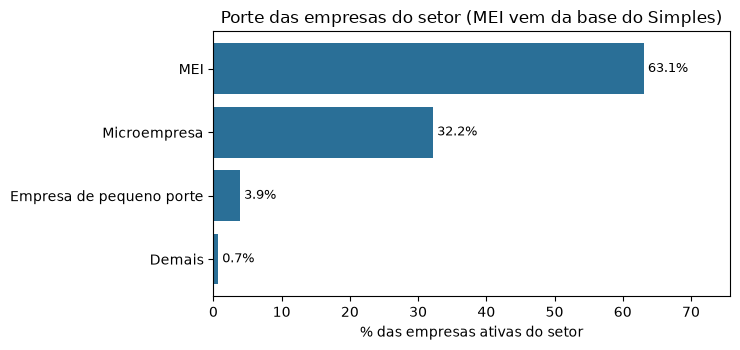

,categoria,empresas,percentual
0,MEI,953769,63.1
1,Microempresa,486715,32.2
2,Empresa de pequeno porte,59403,3.9
3,Demais,11245,0.7


In [9]:
porte = con.sql('''
    SELECT CASE WHEN mei = 'MEI' THEN 'MEI' ELSE porte END AS categoria,
           count(DISTINCT cnpj_basico) AS empresas
    FROM base
    WHERE situacao = 'Ativa'
    GROUP BY 1 ORDER BY 2 DESC
''').df()
porte["percentual"] = (porte["empresas"] / porte["empresas"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
barras = ax.barh(porte["categoria"], porte["percentual"], color="#2a6f97")
ax.invert_yaxis()
ax.set_xlabel("% das empresas ativas do setor")
ax.set_title("Porte das empresas do setor (MEI vem da base do Simples)")
for barra, valor in zip(barras, porte["percentual"]):
    ax.text(barra.get_width(), barra.get_y() + barra.get_height() / 2,
            f" {valor:.1f}%", va="center", fontsize=9)
ax.margins(x=0.2)
plt.tight_layout()
plt.show()

porte

O setor é micro e pequeno, com folga: **MEI responde por 63,1% das empresas ativas** (953.769 de
1.511.132). Depois vêm microempresa, com 32,2%, empresa de pequeno porte, com 3,9%, e uma sobra
de 0,7% em "demais".

Duas checagens que valem registrar, porque MEI é a resposta da pergunta e errar aqui derruba
tudo:

1. **A regra de MEI está certa?** O arquivo do Simples marca a opção pelo MEI e também a data de
   saída do regime. Das 953.769 empresas MEI ativas, só 292 têm data de exclusão preenchida, e
   todas as 292 com data no futuro (fim de 2026), ou seja, saída programada. As que saíram no
   passado aparecem como "não MEI", que é o correto. Então o campo está sendo lido pelo que ele
   significa.
2. **O regime tributário acompanha o porte:** 87% das empresas ativas do setor são optantes do
   Simples Nacional (1.314.662 de 1.511.132). Um setor de micro e pequeno, em regime
   simplificado, e de dono único.

Sobre o tamanho econômico: olhando os estabelecimentos ativos do setor, o capital social mediano da
empresa é de **R$ 5.000** e nove em cada dez ficam abaixo de R$ 60.000. A média passa de R$ 3
milhões, mas isso é distorção de poucos casos grandes, então a mediana conta a história melhor.

Juntando com a pergunta 2, o retrato é coerente: um setor que abre muito, em negócio próprio de
porte mínimo, e que fecha muito também — a seção de safras mais à frente mostra o quanto.

## Perguntas que os dados pediram no caminho

### Que tipo de negócio puxa o setor

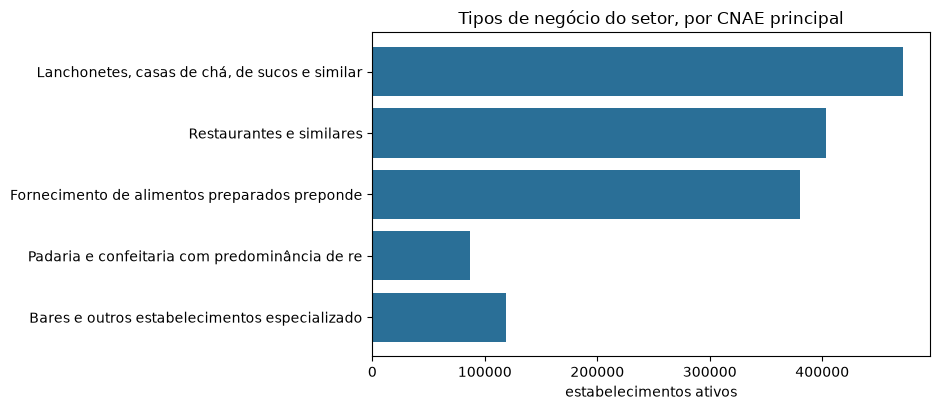

,cnae_descricao,estabelecimentos,empresas
0,"Lanchonetes, casas de chá, de sucos e similares",472218,457164
1,Restaurantes e similares,403467,392378
2,Fornecimento de alimentos preparados preponder...,380242,378296
3,Bares e outros estabelecimentos especializados...,119157,118711
4,Padaria e confeitaria com predominância de rev...,87081,85539
5,Bares e outros estabelecimentos especializados...,81102,80826


In [10]:
tipos = con.sql('''
    SELECT cnae_descricao, count(*) AS estabelecimentos, count(DISTINCT cnpj_basico) AS empresas
    FROM base WHERE situacao = 'Ativa'
    GROUP BY 1 ORDER BY 2 DESC
''').df()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.barh(tipos["cnae_descricao"].str.slice(0, 45)[::-1], tipos["estabelecimentos"][::-1], color="#2a6f97")
ax.set_xlabel("estabelecimentos ativos")
ax.set_title("Tipos de negócio do setor, por CNAE principal")
plt.tight_layout()
plt.show()

tipos

Lanchonete e casa de suco lideram, com 472.218 estabelecimentos ativos, à frente de restaurante
(403.467) e do fornecimento de comida para consumo em casa, que é a cozinha de delivery, com
380.242. Padaria, que é o único CNAE da lista que também vende mercearia, aparece em quinto
(87.081): padaria hoje é mais lanchonete com balcão do que padaria.

### Onde ficam esses negócios

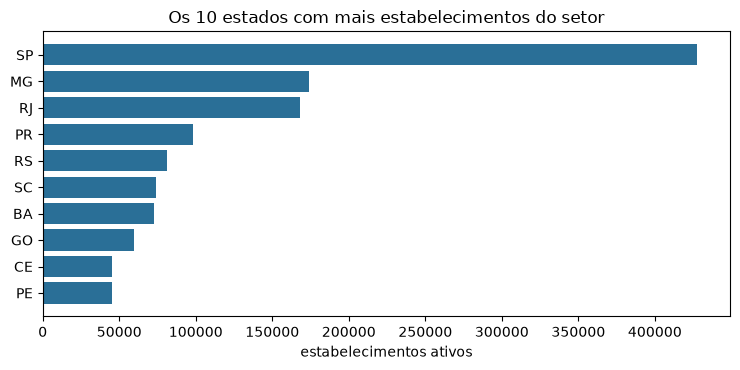

In [11]:
uf = con.sql('''
    SELECT uf, count(*) AS estabelecimentos
    FROM base WHERE situacao = 'Ativa'
    GROUP BY 1 ORDER BY 2 DESC LIMIT 10
''').df()

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(uf["uf"][::-1], uf["estabelecimentos"][::-1], color="#2a6f97")
ax.set_xlabel("estabelecimentos ativos")
ax.set_title("Os 10 estados com mais estabelecimentos do setor")
plt.tight_layout()
plt.show()

São Paulo concentra 427.708 estabelecimentos ativos, 27,7% do setor. Minas (11,3%) e Rio (10,9%)
vêm depois, e o restante se espalha. Qualquer ação nacional do setor que ignore São Paulo está
deixando de fora quase um terço do público.

### Quanto tempo dura um negócio do setor

Este é o corte que eu acho mais útil para uma associação de bares e restaurantes: para cada ano de
abertura, quanto daquela safra já foi encerrado.

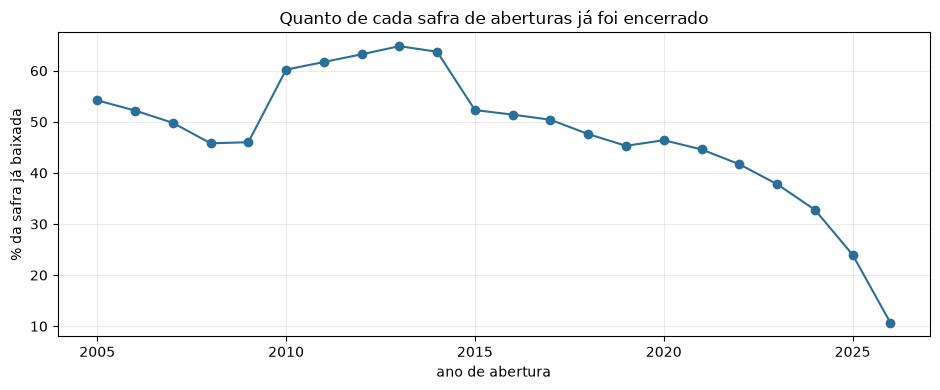

,ano,abertos,baixados,percentual_baixado
14,2019,267701,121168.0,45.3
15,2020,325516,150982.0,46.4
16,2021,356849,159039.0,44.6
17,2022,282586,117965.0,41.7
18,2023,268190,101299.0,37.8
19,2024,284904,93536.0,32.8
20,2025,315376,75747.0,24.0
21,2026,230057,24519.0,10.7


In [12]:
safras = con.sql('''
    SELECT ano_inicio AS ano,
           count(*)                                        AS abertos,
           sum(CASE WHEN situacao = 'Baixada' THEN 1 END)   AS baixados
    FROM base
    WHERE ano_inicio BETWEEN 2005 AND 2026
    GROUP BY 1 ORDER BY 1
''').df()
safras["percentual_baixado"] = (safras["baixados"] / safras["abertos"] * 100).round(1)

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(safras["ano"], safras["percentual_baixado"], marker="o", color="#2a6f97")
ax.set_xlabel("ano de abertura")
ax.set_ylabel("% da safra já baixada")
ax.set_title("Quanto de cada safra de aberturas já foi encerrado")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

safras.tail(8)

Mais da metade de cada safra fecha. Das empresas do setor abertas em 2013, 64,8% já estão
baixadas. A curva sobe conforme a safra envelhece, o que é esperado: o negócio tem mais tempo de
fechar. É o retrato de um setor de porta que gira rápido, e é o número que muda a conversa sobre
apoio a quem abre.

Uma pergunta que ficou aberta e que dá para responder com esta base: separar MEI de não MEI nessa
curva. Se o MEI fecha mais rápido que a microempresa, isso muda o desenho de política de apoio.

## O que estes dados mostram, e o que não mostram

O que dá para afirmar, com a base completa:

- o setor tem **1.511.132 empresas ativas** hoje, quase todas de endereço único (97,6% matriz);
- **MEI é o porte predominante**, com 63,1% das empresas ativas, seguido de microempresa (32,2%) e
  empresa de pequeno porte (3,9%);
- a abertura de pontos **cresceu de 2005 até 2021**, recuou em 2022 e 2023 e retomou a partir de
  2024, com 2025 perto do pico;
- a alimentação fora do lar representa de 6% a 8,6% de todas as aberturas do país, e essa fatia
  **caiu** nos últimos anos, mesmo com o setor abrindo mais em número absoluto;
- mais da metade de cada safra de aberturas acaba encerrada, e a curva de fechamento por safra
  mostra que o negócio gira rápido.

O que **não** dá para afirmar com o que está aqui: faturamento, empregos, ou se o negócio que
fechou foi substituído por outro no mesmo ponto. A base diz quantos e onde, não quanto. Para isso
seria preciso cruzar com outra fonte, tipo a RAIS ou a pesquisa mensal de serviços.

Sobre o processo: o caminho que sobrou foi o certo, mas custou caro. Se o objetivo é só responder
essas três perguntas de novo, dá para fazer com as partes 0, 4 e 5 e chegar perto nos anos
recentes; para série longa e número absoluto confiável, tem que ser as 10.